## COMPRENDER LOS DATOS DEL DATASET

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columnas = ['symboling', 'perdidas_normal', 'marca', 'combustible', 'inyección',
            'puertas', 'chasis', 'traccion', 'lugar_de_motor', 'potencia_base',
            'longitud', 'anchura', 'altura', 'peso', 'tipo_motor',
            'cilindros', 'tamaño_motor', 'sistema', 'calibre', 'ataque',
            'ratio_compresion', 'potencia_cv', 'max_rpm', 'consumo_carretera', 'consumo_ciudad',
            'precio']

autos = pd.read_csv("seguros_de_coches.csv", header=None, names=columnas, na_values='?', delimiter=",")

## DATOS AUSENTES Y CATEGÓRICOS

In [2]:
# Valores ausentes y columnas categóricas
print("========== Valores ausentes:\n", autos.isna().sum())

cols_categoricas = autos.select_dtypes(include=["object"]).columns
#cols_categoricas = ["marca", "sistema"]  # Completa el array!!!
autos[cols_categoricas] = autos[cols_categoricas].astype("category")

autos["puertas"] = pd.Categorical(autos["puertas"], categories=["two", "four"], ordered=True)

autos["cilindros"] = pd.Categorical(autos["cilindros"],
                                    categories=["two", "three", "four", "five", "six", "eight", "twelve"],
                                    ordered=True)

print("========== Cambiamos a tipo category:\n", autos.info())

========== Valores ausentes:
 symboling             0
perdidas_normal      37
marca                 0
combustible           0
inyección             0
puertas               2
chasis                0
traccion              0
lugar_de_motor        0
potencia_base         0
longitud              0
anchura               0
altura                0
peso                  0
tipo_motor            0
cilindros             0
tamaño_motor          0
sistema               0
calibre               4
ataque                4
ratio_compresion      0
potencia_cv           2
max_rpm               2
consumo_carretera     0
consumo_ciudad        0
precio                0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   symboling          201 non-null    int64   
 1   perdidas_normal    164 non-null    float64 
 2   marca              201 non-

In [3]:
cols_categoricas_escasas = []

for col in cols_categoricas:
    print(autos[col].value_counts())
    print("")

marca
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
chevrolet         3
alfa-romeo        3
jaguar            3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64

combustible
gas       181
diesel     20
Name: count, dtype: int64

inyección
std      165
turbo     36
Name: count, dtype: int64

puertas
four    113
two      86
Name: count, dtype: int64

chasis
sedan          94
hatchback      68
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

traccion
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

lugar_de_motor
front    198
rear       3
Name: count, dtype: int64

tipo_motor
ohc      145
ohcf      15
ohcv      13
dohc      12
l         12
r

## ESTUDIAR ESTADÍSTICAS DE PAREJAS DE VARIABLES

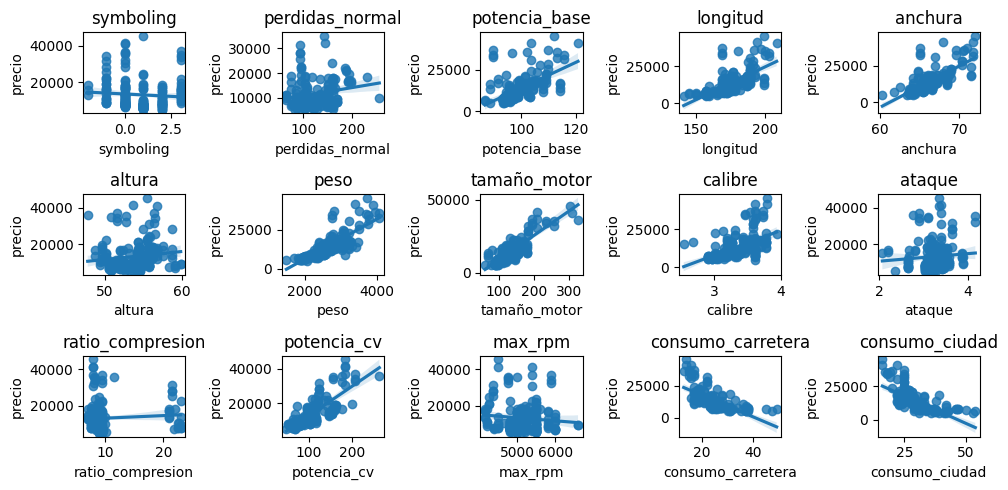

In [4]:
# ===== Análisis bivariable
# Generar listado de variables numéricas excepto target
cols_numericas = (autos.drop(columns=["precio"])
                  .select_dtypes(include=np.number)
                  .columns.tolist())

n_cols_numericas = len(cols_numericas)  # Gráficos de regresión simple con target

import seaborn as sns
import math

fig, ejes = plt.subplots(math.ceil(n_cols_numericas / 5), 5, figsize=(10, 5))  # Son 15, plot de 5 columnas
ejes = ejes.flatten()

for i, col in enumerate(cols_numericas):
    sns.regplot(data=autos, x=col, y="precio", ax=ejes[i])
    ejes[i].set_title(col)

plt.tight_layout()
plt.show()

---
### a) Cuando se genere el primer gráfico, busca una de las características que no tengan una relación lineal con el target. La eliminas del DataFrame y de los arrays de nombres de columnas en el fichero _v2. Indica qué característica eliminas:
Hay varias características que no tienen una relación lineal con el target. Yo he elegido "altura" para eliminar.

In [5]:
autos = autos.drop('altura', axis=1)
columnas.remove('altura')

---

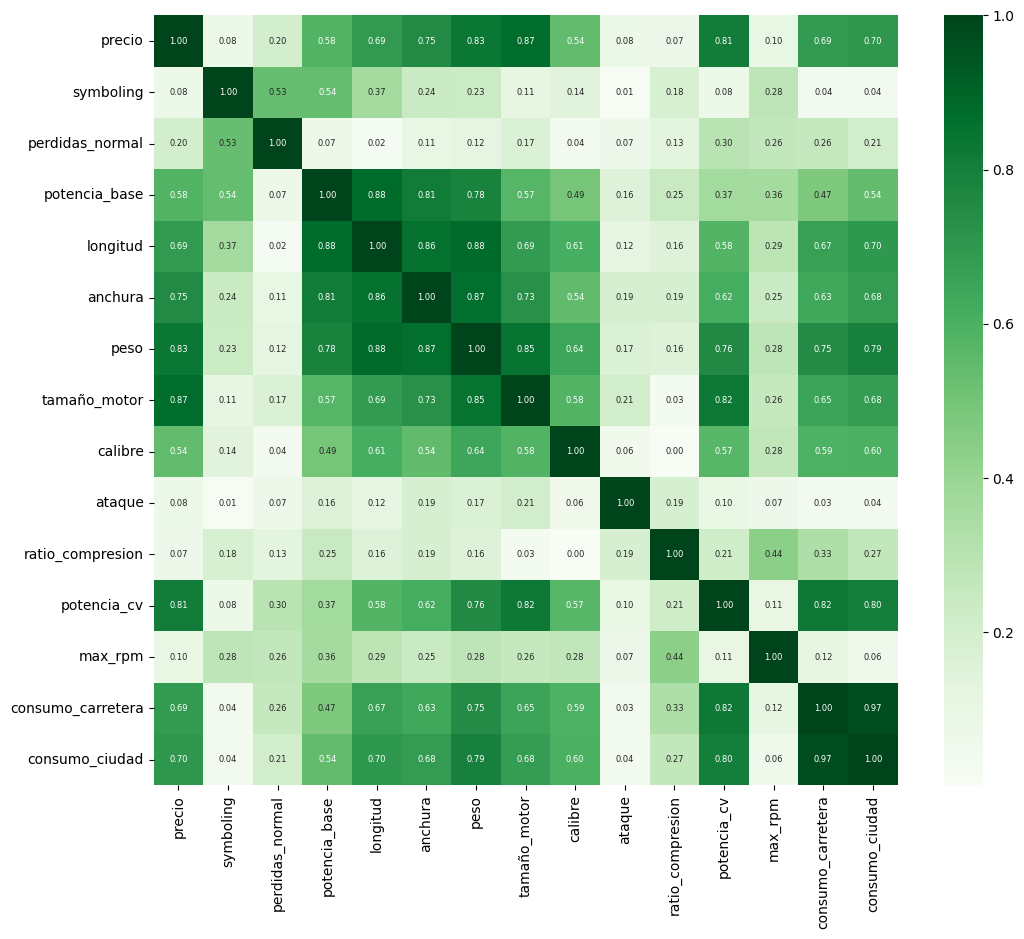

In [6]:
from matplotlib.colors import Colormap as cm

cols = autos.columns.tolist()  # mover la columna precio al inicio del dataframe
cols.insert(0, cols.pop(cols.index("precio")))
autos = autos.reindex(columns=cols)
autos_matriz_correlaciones = autos.corr(numeric_only=True)
fig, ejes = plt.subplots(figsize=(12, 10))
absoluta = autos_matriz_correlaciones.abs()
sns.heatmap(absoluta, annot=True, annot_kws={'size':6}, fmt=".2f", cmap="Greens")
plt.show()

---
### b) Cuando aparezca la matriz de correlaciones, identifica las características que tengan menos del 0.2% de correlación lineal con el target y las eliminas del DataFrame en el nuevo fichero. ¿Cuáles son las variables que eliminas?
Las variables que voy a eliminar con menos de un 0'2% de correlación lineal con el target son: symboling, ataque, ratio_compresion y max_rpm.

In [7]:
print(autos.columns)
autos = autos.drop(['symboling', 'ataque', 'ratio_compresion', 'max_rpm'], axis=1)
print(autos.columns)

Index(['precio', 'symboling', 'perdidas_normal', 'marca', 'combustible',
       'inyección', 'puertas', 'chasis', 'traccion', 'lugar_de_motor',
       'potencia_base', 'longitud', 'anchura', 'peso', 'tipo_motor',
       'cilindros', 'tamaño_motor', 'sistema', 'calibre', 'ataque',
       'ratio_compresion', 'potencia_cv', 'max_rpm', 'consumo_carretera',
       'consumo_ciudad'],
      dtype='object')
Index(['precio', 'perdidas_normal', 'marca', 'combustible', 'inyección',
       'puertas', 'chasis', 'traccion', 'lugar_de_motor', 'potencia_base',
       'longitud', 'anchura', 'peso', 'tipo_motor', 'cilindros',
       'tamaño_motor', 'sistema', 'calibre', 'potencia_cv',
       'consumo_carretera', 'consumo_ciudad'],
      dtype='object')


---
---

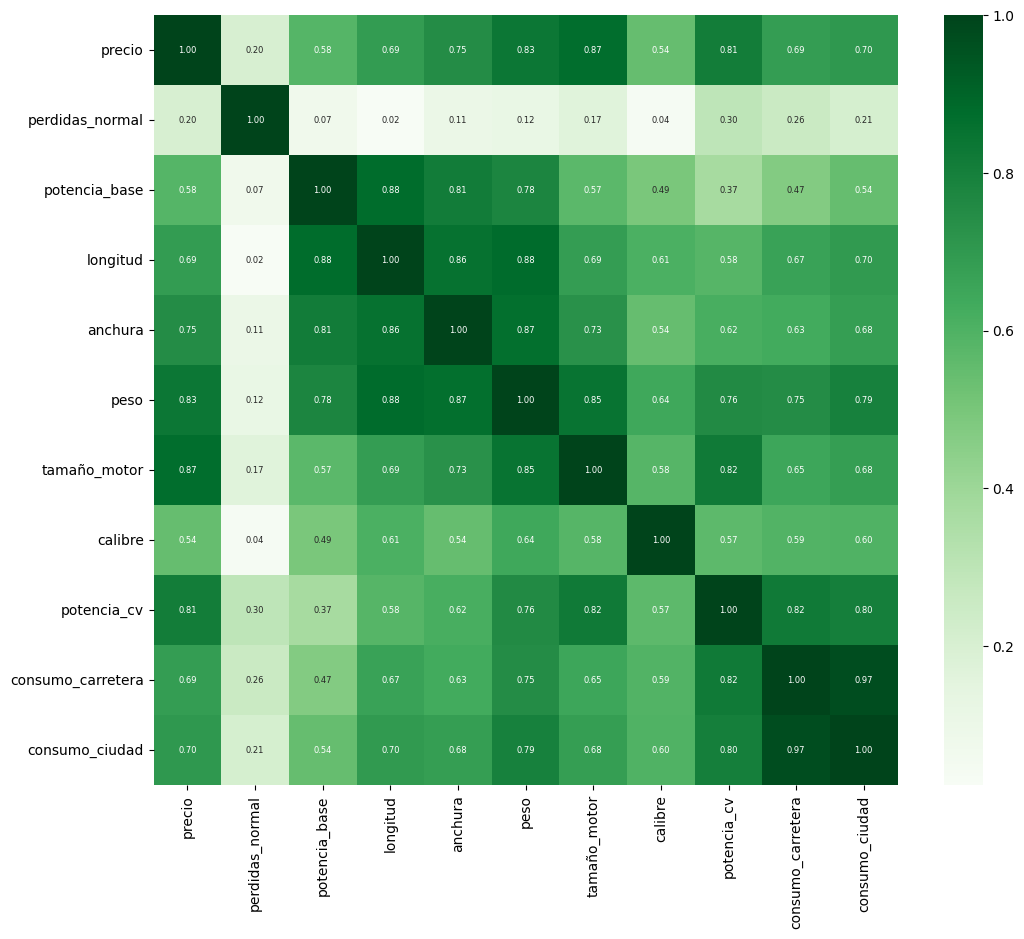

In [8]:
from matplotlib.colors import Colormap as cm

cols = autos.columns.tolist()  # mover la columna precio al inicio del dataframe
cols.insert(0, cols.pop(cols.index("precio")))
autos = autos.reindex(columns=cols)
autos_matriz_correlaciones = autos.corr(numeric_only=True)
fig, ejes = plt.subplots(figsize=(12, 10))
absoluta = autos_matriz_correlaciones.abs()
sns.heatmap(absoluta, annot=True, annot_kws={'size':6}, fmt=".2f", cmap="Greens")
plt.show()

### c) Además, para eliminar colinealidad localiza todas las parejas (puedes ir bajando desde la primera a la última fila y buscar y eliminar correlaciones mayores de 0.8 que no sea con el target). ¿Qué columnas has eliminado?
Correlaciones mayores de 0.8:
 - potencia_base - longitud = 0.88
 - potencia_base - anchura = 0.81
 - longitud - anchura = 0.86
 - longitud - peso = 0.88
 - anchura - peso = 0.87
 - tamaño_motor - peso = 0.85
 - tamaño_motor - potencia_cv = 0.82
 - potencia_cv - consumo_carretera = 0.82
 - consumo_carretera - consumo_ciudad = 0.97

Columnas que he seleccionado para eliminar:
 - potencia_base
 - longitud
 - anchura
 - tamaño_motor
 - potencia_cv
 - consumo_carretera

In [9]:
autos = autos.drop(['potencia_base', 'longitud', 'anchura', 'tamaño_motor', 'potencia_cv', 'consumo_carretera'], axis=1)
print(autos.columns)

Index(['precio', 'perdidas_normal', 'marca', 'combustible', 'inyección',
       'puertas', 'chasis', 'traccion', 'lugar_de_motor', 'peso', 'tipo_motor',
       'cilindros', 'sistema', 'calibre', 'consumo_ciudad'],
      dtype='object')


---

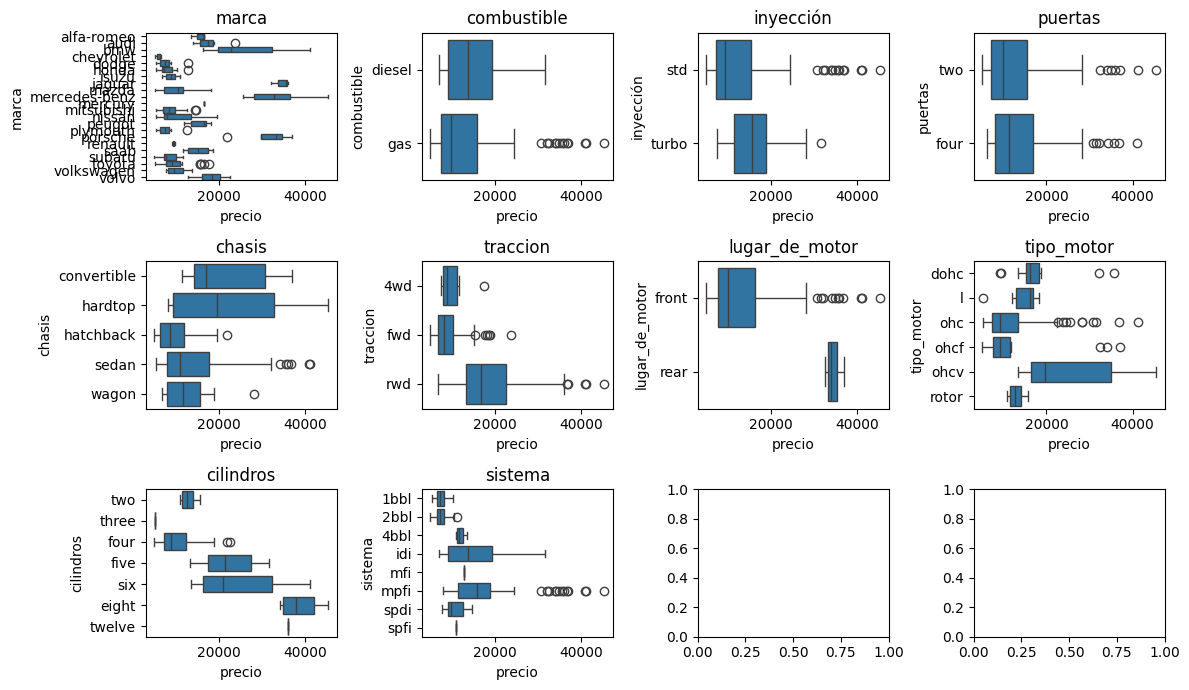

In [10]:
# Gráficos boxplot de categóricas con el target
n_categoricas = len(cols_categoricas)
fig, ejes = plt.subplots(n_categoricas // 4 + 1, 4, figsize=(12, 7))
ejes = ejes.flatten()

for i, col in enumerate(cols_categoricas):
    sns.boxplot(data=autos, x="precio", y=col, ax=ejes[i])
    ejes[i].set_title(col)

plt.tight_layout()
plt.show()

---
### d) En los diagramas boxplot de las columnas categóricas, elimina una o dos que no genere diferencias importantes entre sus valores (las identificas porque los boxplot de cada valor serán parecidos). ¿Cuáles eliminas?

He decidido eliminar una variable de cada columna categórica:
 - **Mitsubushi**, debido a su similitud con Toyota.
 - **2bbl**, debido a su similitud con 1bbl.

In [11]:
autos = autos[autos['marca'] != 'mitsubishi']
print(autos['marca'].value_counts())

marca
toyota           32
nissan           18
mazda            17
honda            13
subaru           12
volkswagen       12
peugot           11
volvo            11
dodge             9
bmw               8
mercedes-benz     8
plymouth          7
audi              6
saab              6
porsche           4
alfa-romeo        3
chevrolet         3
jaguar            3
isuzu             2
renault           2
mercury           1
mitsubishi        0
Name: count, dtype: int64


In [12]:
autos = autos[autos['sistema'] != '2bbl']
print(autos['sistema'].value_counts())

sistema
mpfi    92
idi     20
1bbl    11
4bbl     3
spdi     2
mfi      1
spfi     1
2bbl     0
Name: count, dtype: int64


---

## FASE DE INGENIERÍA DE CARACTERÍSTICAS

In [13]:
#========== Ingeniería de Características ==========
from sklearn.pipeline import Pipeline  # librerías de preprocesamiento de datos
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

y = autos['precio']  # quitamos el precio de las predictoras
X = autos.drop('precio', axis='columns')

# Distribuir columnas predictoras en 1 de estas categorías
cols_categoricas = ["marca", "combustible", "inyección", "chasis", "traccion", 
                    "lugar_de_motor", "tipo_motor", "sistema"]
cols_categoricas_ordinales = ["puertas", "cilindros"]
cols_todas = X.columns.tolist()
cols_numericas = [x for x in cols_todas if x not in cols_categoricas and x not in cols_categoricas_ordinales]

print("Predictoras ordinales:", cols_categoricas_ordinales)
print("Predictoras categóricas:", cols_categoricas)
print("Predictoras numéricas:", cols_numericas)

pipe_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_categoricas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

pipe_categoricas_ordinales = Pipeline(steps=[
    ('ordenc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocesa_columnas = ColumnTransformer(transformers=[
    ('numericas', pipe_numericas, cols_numericas),
    ('categoricas', pipe_categoricas, cols_categoricas),
    ('categoricas_ordinales', pipe_categoricas_ordinales, cols_categoricas_ordinales)
])

Predictoras ordinales: ['puertas', 'cilindros']
Predictoras categóricas: ['marca', 'combustible', 'inyección', 'chasis', 'traccion', 'lugar_de_motor', 'tipo_motor', 'sistema']
Predictoras numéricas: ['perdidas_normal', 'peso', 'calibre', 'consumo_ciudad']


## DIVIDIR EL DATASET EN TRAIN Y TEST

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
print("Dimensiones de train:", x_train.shape)
print("Dimensiones de test:", x_test.shape)

Dimensiones de train: (104, 14)
Dimensiones de test: (26, 14)


## BUSCAR UN BUEN MODELO DE REGRESIÓN

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings("ignore")

# Diccionario para almacenar los resultados del entrenamiento
dic_resultados = {}  # {clave: {train_score, test_score}, ...}

def entrenar_modelo(modelo, procesador, X: pd.DataFrame, y: pd.Series, pct_test: float=0.2):
    x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=pct_test)
    pipe = Pipeline(steps=[("preprocessor", procesador), ("model", modelo)])
    modelo_entrenado = pipe.fit(x_train, y_train)
    train_score = modelo_entrenado.score(x_train, y_train)
    test_score = modelo_entrenado.score(x_test, y_test)

    return {'train_score': train_score, 'test_score': test_score}

In [16]:
def compara_resultados():
    for key in dic_resultados:
        print('Regresión:', key)
        print(f' train_score: {dic_resultados[key]["train_score"]:10.6f}')
        print(f' test_score: {dic_resultados[key]["test_score"]:10.6f}')
        print()

In [17]:
dic_resultados['Dummy'] = entrenar_modelo(DummyRegressor(strategy='median'), preprocesa_columnas, x_train, y_train)
# dic_resultados['Regresión Lineal'] = entrenar_modelo(LinearRegression(), preprocesa_columnas, x_train, y_train)
dic_resultados['Lasso'] = entrenar_modelo(Lasso(alpha=0.1), preprocesa_columnas, x_train, y_train)
dic_resultados['Ridge'] = entrenar_modelo(Ridge(alpha=0.1), preprocesa_columnas, x_train, y_train)
dic_resultados['Elasticnet'] = entrenar_modelo(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, warm_start=True), preprocesa_columnas, x_train, y_train)

pipe_poli = Pipeline([('polynomial_features', PolynomialFeatures(degree=3, include_bias=False)),
                      ('linear_regressor', LinearRegression())])
dic_resultados['Polinomial'] = entrenar_modelo(pipe_poli, preprocesa_columnas, x_train, y_train)
dic_resultados['KNN'] = entrenar_modelo(KNeighborsRegressor(n_neighbors=5), preprocesa_columnas, x_train, y_train)

compara_resultados()

Regresión: Dummy
 train_score:  -0.078595
 test_score:  -0.242960

Regresión: Lasso
 train_score:   0.954366
 test_score:   0.849212

Regresión: Ridge
 train_score:   0.954010
 test_score:   0.854487

Regresión: Elasticnet
 train_score:   0.910079
 test_score:   0.822967

Regresión: Polinomial
 train_score:   0.999679
 test_score: -23.211239

Regresión: KNN
 train_score:   0.801214
 test_score:   0.761298



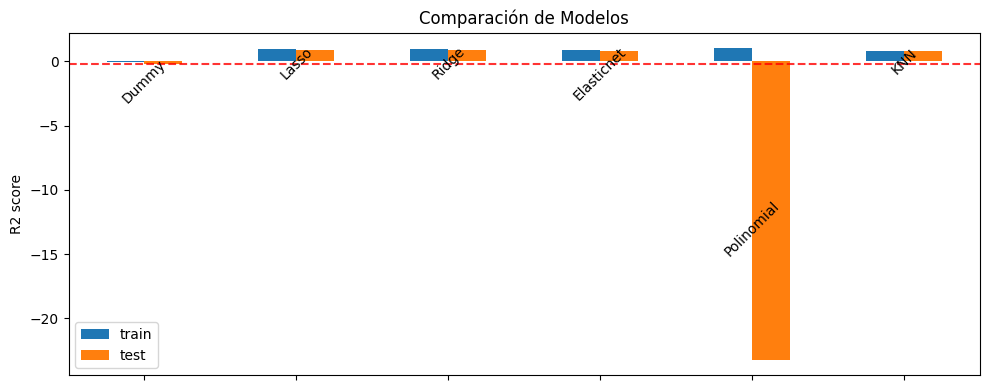

In [18]:
# Crear diccionarios para almacenar los resultados de prueba y entrenamiento
nombre_modelos = dic_resultados.keys()
res_test = {}
res_train = {}

for nombre in nombre_modelos:
    res_train[nombre] = dic_resultados[nombre]['train_score']
    res_test[nombre] = dic_resultados[nombre]['test_score']

df_comparacion = pd.DataFrame([res_train, res_test], index=['train', 'test'])

# Dibujar un gráfico de barras
fig, ax = plt.subplots(figsize=(10, 4))
df_comparacion.T.plot(kind='bar', ax=ax)
ax.set_ylabel('R2 score')
ax.set_title('Comparación de Modelos')

# Dibujar etiquetas dentro de las barras rotadas 90 grados
ax.set_xticks(range(len(df_comparacion.columns)))
ax.set_xticklabels([])  # Ocultar etiquetas del eje x

for i, label in enumerate(df_comparacion.columns):
    bar_center = (df_comparacion.loc['train', label] + df_comparacion.loc['test', label]) / 2
    ax.text(i, bar_center, label, ha='center', va='center_baseline', rotation=45)

# Dibujar una línea para el resultado del DummyRegressor
ax.axhline(df_comparacion['Dummy']['test'], color='red', linestyle='--', alpha=0.8)  # Línea discontinua

plt.tight_layout()
plt.show()

---
### e) En el paso de "Buscar un buen modelo de regresión" descarta los 3 peores (aquellos que tengan peor R2 en los datos de test). Muestra captura de scores y el gráfico e indica los modelos que descartas.

Los 3 modelos que he decidido descartar, debido a que han obtenido los peores R2 en los datos de test, han sido:
 - Polinomial: -23.211239 de score.
 - Dummy: -0.242960 de score.
 - KNN: 0.761298 de score.

Capturas:

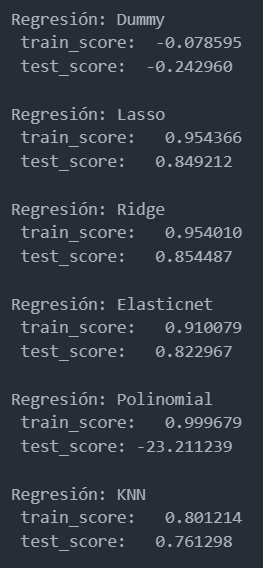

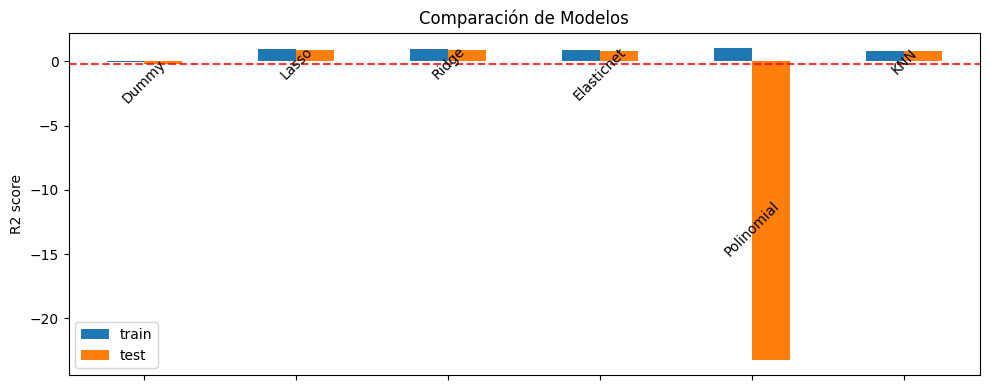

In [19]:
del dic_resultados['Dummy']
del dic_resultados['Polinomial']
del dic_resultados['KNN']

print(dic_resultados)

{'Lasso': {'train_score': 0.9543661602685214, 'test_score': 0.8492119036702025}, 'Ridge': {'train_score': 0.9540104443892793, 'test_score': 0.854487332611418}, 'Elasticnet': {'train_score': 0.9100786883247689, 'test_score': 0.8229666274416492}}


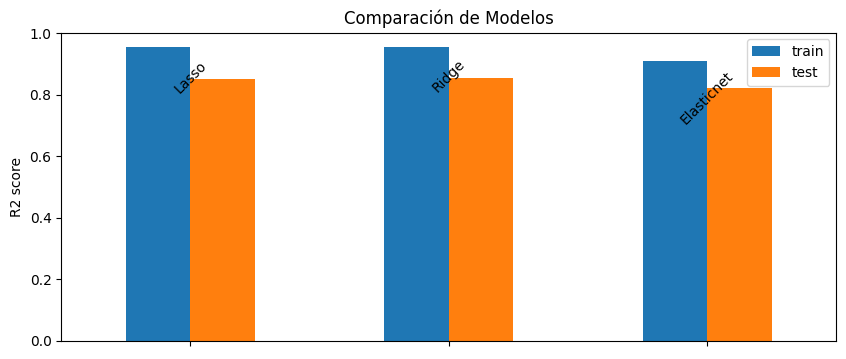

In [20]:
# Crear diccionarios para almacenar los resultados de prueba y entrenamiento
nombre_modelos = dic_resultados.keys()
res_test = {}
res_train = {}

for nombre in nombre_modelos:
    res_train[nombre] = dic_resultados[nombre]['train_score']
    res_test[nombre] = dic_resultados[nombre]['test_score']

df_comparacion = pd.DataFrame([res_train, res_test], index=['train', 'test'])

# Dibujar un gráfico de barras
fig, ax = plt.subplots(figsize=(10, 4))
df_comparacion.T.plot(kind='bar', ax=ax)
ax.set_ylabel('R2 score')
ax.set_title('Comparación de Modelos')

# Dibujar etiquetas dentro de las barras rotadas 90 grados
ax.set_xticks(range(len(df_comparacion.columns)))
ax.set_xticklabels([])  # Ocultar etiquetas del eje x

for i, label in enumerate(df_comparacion.columns):
    bar_center = (df_comparacion.loc['train', label] + df_comparacion.loc['test', label]) / 2
    ax.text(i, bar_center, label, ha='center', va='center_baseline', rotation=45)


---

## VALIDACIÓN CRUZADA

In [21]:
# Lista para almacenar los modelos seleccionados para validación cruzada
modelos = []

# Almacenando los modelos como una tupla (nombre, modelo)
modelos.append(('Lasso', Lasso(alpha=0.1)))
modelos.append(('Elastic_net', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, warm_start=True)))
modelos.append(('Ridge', Ridge(alpha=0.1)))

(10-Fold CV de Lasso, media: 0.8316446069927471, desviación: 0.08917570967428377)
(10-Fold CV de Elastic_net, media: 0.8406240467147755, desviación: 0.07235756279938937)
(10-Fold CV de Ridge, media: 0.8657873896999811, desviación: 0.06028726210683906)


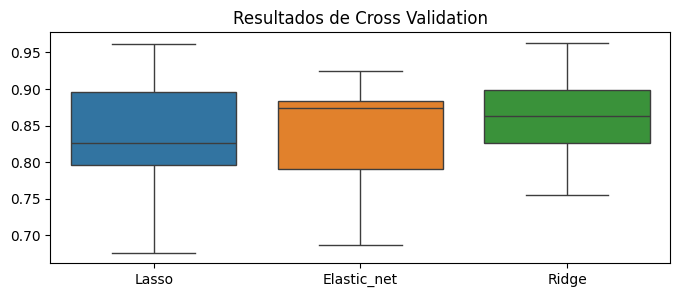

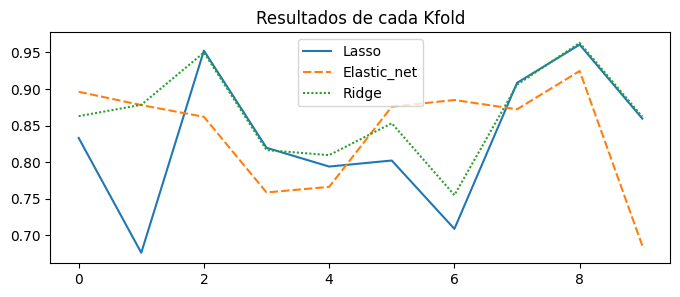

In [22]:
from sklearn import model_selection

# Grabar los resultados de cada modelo
seed = 123      # Semilla para obtener los mismos resultados de pruebas
resultados = []
nombres = []  # Lista para guardar los nombres de los modelos

for n, m in modelos:
    kfold = model_selection.KFold(n_splits=10)  # Kfold cross validation
    modelo_pipe = Pipeline(steps=[("preprocessor", preprocesa_columnas), ("model", m)])
    cv_resultados = model_selection.cross_val_score(estimator=modelo_pipe, X=x_train, y=y_train, cv=kfold, scoring="r2")
    resultados.append(cv_resultados)
    nombres.append(n)
    msg = f"(10-Fold CV de {n}, media: {cv_resultados.mean()}, desviación: {cv_resultados.std()})"
    print(msg)

plt.figure(figsize=(8, 3))
result_df = pd.DataFrame(resultados, index=nombres).T
sns.boxplot(data=result_df)
plt.title("Resultados de Cross Validation")
plt.show()

plt.figure(figsize=(8, 3))
sns.lineplot(data=result_df)
plt.title("Resultados de cada Kfold")
plt.show()

In [23]:
from scipy.stats import f_oneway

# Comparación estadística de los modelos
model1 = result_df['Lasso']
model2 = result_df['Ridge']
model3 = result_df['Elastic_net']

estadistico, p_value = f_oneway(model1, model2, model3)
print(f'Estadístico: {estadistico}')
print(f'p_value: {p_value}')

# Test de contraste de hipótesis con los datos obtenidos
alfa = 0.05  # Nivel de significancia

if p_value < alfa:
    print("Existe una diferencia estadísticamente significativa en los resultados de cross-validation de los modelos.")
else:
    print("No existe una diferencia estadísticamente significativa en los resultados de cross-validation de los modelos.")

Estadístico: 0.5027791965989905
p_value: 0.6103987359209606
No existe una diferencia estadísticamente significativa en los resultados de cross-validation de los modelos.


---
### f) En la validación cruzada, utiliza solamente los 3 mejores modelos del paso anterior. Muestra captura de resultados y escoge aquel que tenga menor varianza (es más estable).
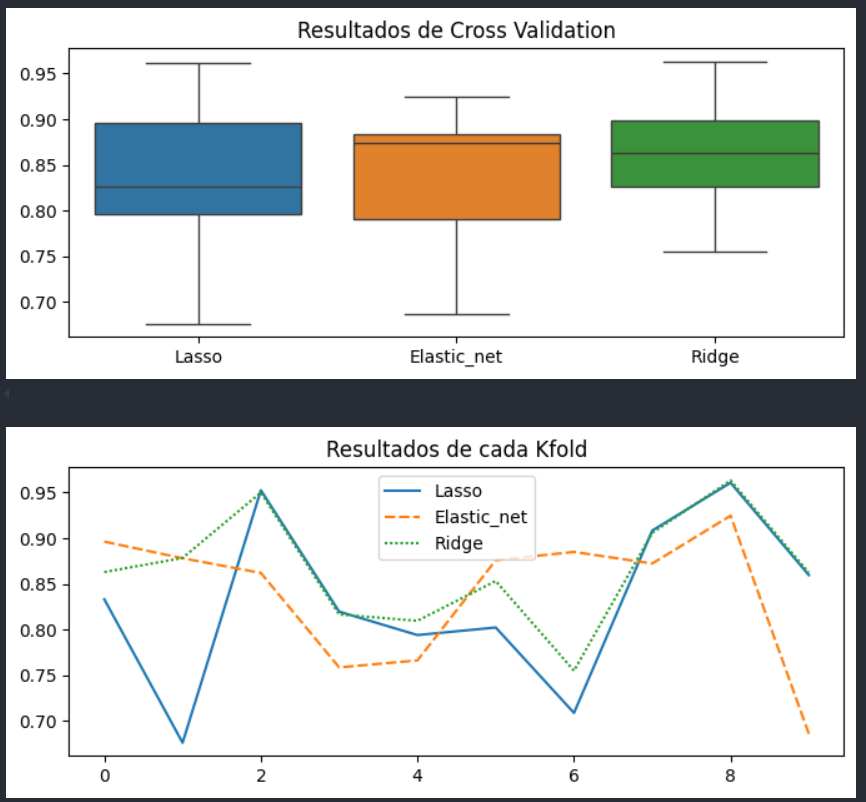

A partir de estos resultados, he seleccionado el modelo `Elastic Net`, debido a que es el que tiene menor varianza.

---

---
### g) En el tunning de hiperparámetros, busca los parámetros que se puedan usar con el modelo con el que te has quedado (si das uno erróneo al grid search, el mensaje de error te dice los que puedes usar). Indica captura de ejecución de esta fase y del entrenamiento del modelo elegido con los datos de train y test.

## TUNING DE HIPERPARÁMETROS

In [24]:
from sklearn.model_selection import GridSearchCV

#=========== Tuning de parámetros
#=== Para Elastic Net
print("----- Elastic Net -----")
elastic_pipe = Pipeline(steps=[("preprocessor", preprocesa_columnas), ("model", ElasticNet())])
parametros = {
    'model__alpha': [0.01, 0.1, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
gs = GridSearchCV(elastic_pipe, parametros, cv=5, return_train_score=True, scoring='r2')
gs.fit(x_train, y_train)

print(f"Mejor resultado = {gs.best_score_}")
print(f"Mejor std = {gs.cv_results_['std_test_score'][gs.best_index_]}")
print(f"Mejores parámetros = {gs.best_params_}")


----- Elastic Net -----
Mejor resultado = 0.877913017987981
Mejor std = 0.036842290044549024
Mejores parámetros = {'model__alpha': 0.01, 'model__l1_ratio': 0.3}


---

## ENTRENAR EL MEJOR MODELO CON LOS MEJORES HIPERPARÁMETROS

In [25]:
from sklearn import metrics

# Entrenamiento, medición y guardado del modelo
elastic_net = ElasticNet(alpha=gs.best_params_['model__alpha'], l1_ratio=gs.best_params_['model__l1_ratio'])

x_train = x_train.select_dtypes(exclude=['object', 'category'])
x_train = x_train.dropna()
elastic_net.fit(x_train, y_train[:len(x_train)])

x_test = x_test.select_dtypes(exclude=['object', 'category'])
x_test = x_test.dropna()
y_pred = elastic_net.predict(x_test)

print("R2:", metrics.r2_score(y_true=y_test[:len(y_pred)], y_pred=y_pred))

R2: -0.015462102450352733


---
### h) Por último, analiza los errores que comete con el test mediante gráficos de predicciones vs valores reales, gráfico de residuos, y gráfico de test de permutaciones para estudiar la importancia de las predictoras en el modelo. Guarda el modelo en un fichero.

R2: -0.015462102450352733


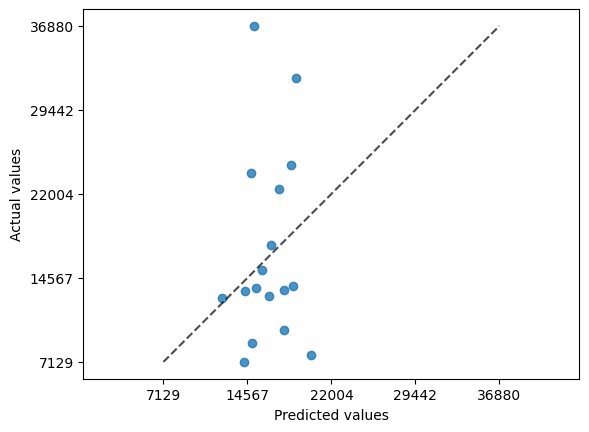

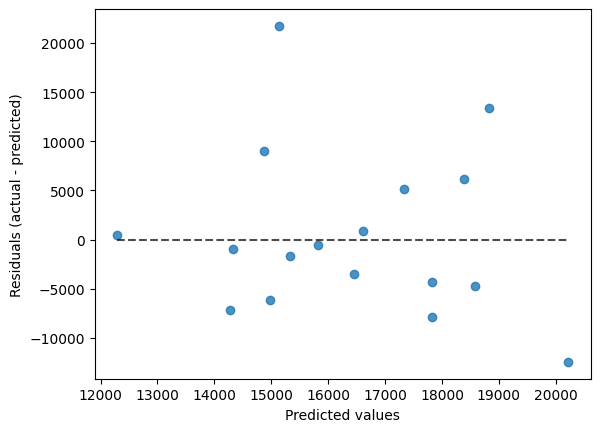

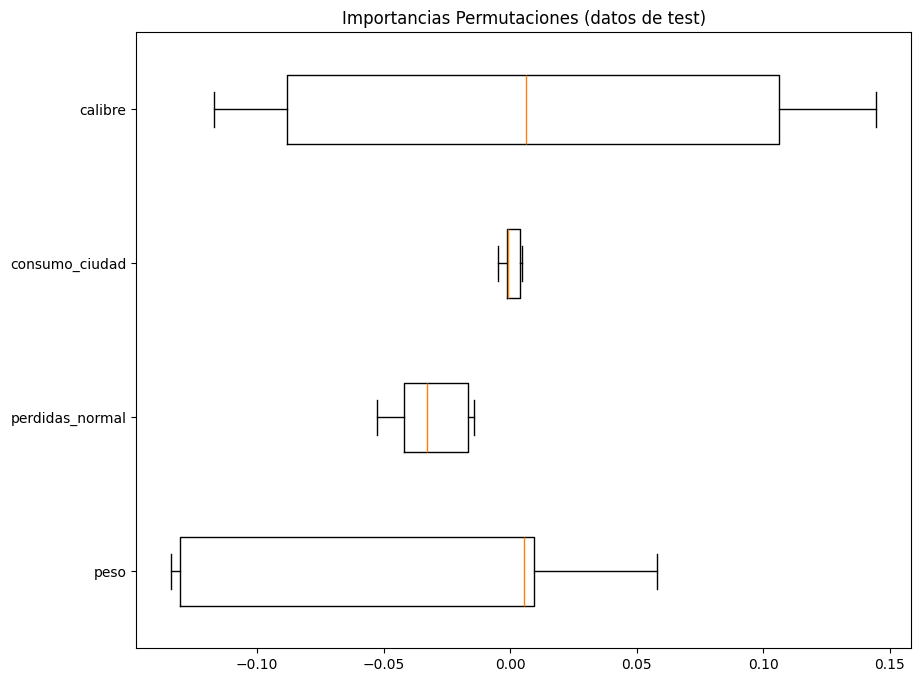

In [26]:
# Entrenar, medir y Guardar el modelo ganador
#--- Suponiendo que haya sido el KNN
from sklearn import metrics

elastic_pipe = ElasticNet(alpha=gs.best_params_['model__alpha'], l1_ratio=gs.best_params_['model__l1_ratio'])
elastic_pipe.fit(x_train, y_train[:len(x_train)])

y_pred = elastic_pipe.predict(x_test)
print("R2:", metrics.r2_score(y_true=y_test[:len(y_pred)], y_pred=y_pred))

from sklearn.metrics import PredictionErrorDisplay
PredictionErrorDisplay.from_predictions(y_true=y_test[:len(y_pred)], y_pred=y_pred, kind="actual_vs_predicted")
plt.show()

PredictionErrorDisplay.from_predictions(y_true=y_test[:len(y_pred)], y_pred=y_pred, kind="residual_vs_predicted")
plt.show()

from sklearn.inspection import permutation_importance
imps = permutation_importance(elastic_pipe, x_test, y_test[:len(x_test)], n_repeats = 5, scoring= "r2", n_jobs=-1, random_state=123)

perm_sorted_idx= imps.importances_mean.argsort()
fig= plt.figure(figsize=(10,8))

plt.boxplot(imps.importances [perm_sorted_idx].T, vert=False, labels=x_test.columns[perm_sorted_idx])
plt.title("Importancias Permutaciones (datos de test)")
plt.show()

In [27]:
from joblib import dump, load
dump(elastic_net, 'modelo_elastic_net.joblib')

modelo = load('modelo_elastic_net.joblib')
modelo.fit(x_train, y_train[:len(x_train)])

datos_prueba = x_test[:1]
print(f"Predicción: {modelo.predict(datos_prueba)}")

Predicción: [16620.51080296]


---